# Chapter 1: What Is a Manifold?

**Source Span.** Thurston, *Three-Dimensional Geometry and Topology, Volume 1*, Chapter 1, printed pages 3-42. The PDF was used only for source orientation: polygons and surfaces, hyperbolic surfaces, the totality of surfaces, and first examples of three-manifolds.

**Chapter goal.** Build a standalone visual route from two-dimensional gluing pictures to the first three-dimensional universes. The chapter begins with the torus as a square with opposite sides identified, then uses covering spaces and hyperbolic geometry to show that local pictures can have global consequences. It next turns Euler characteristic and vector-field index into surface classifiers, and it ends by asking the reader to imagine three-manifolds through cube gluings, projective/lens spaces, dodecahedral gluing, and knot-complement decompositions.

The notebook replaces the old generic scaffold with original teaching prose, diagrams, code, and checks. The examples are deliberately finite and inspectable: a gluing dictionary, a polygon Euler ledger, a Poincare disk construction, a vector-field index diagram, and an applied lab that predicts the surface produced by an edge-pairing word. No textbook figures, page crops, or exercise statements are reproduced.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Polygon, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = 'chapter-01-what-is-a-manifold'
UNIT_TITLE = 'What Is a Manifold?'
ART_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ART_ROOT / 'figures'; HTML = ART_ROOT / 'html'; CHECK = ART_ROOT / 'checks'; TABLE = ART_ROOT / 'tables'
ARTIFACTS = []

def remember(path):
    ARTIFACTS.append(Path(path))
    return Path(path)

plt.rcParams.update({'figure.figsize': (7.6, 5.2), 'axes.spines.top': False, 'axes.spines.right': False})
display(Markdown(f'Artifacts for **{UNIT_TITLE}** will be written under `{ART_ROOT.relative_to(BOOK_ROOT).as_posix()}`.'))


Artifacts for **What Is a Manifold?** will be written under `artifacts/chapter-01-what-is-a-manifold`.

## Visual Storyboard And Library Routing

| Source section | Notebook representation | Inspection target | Validation |
| --- | --- | --- | --- |
| Polygons and surfaces | Square and octagon edge-pairing boards | Opposite-side gluing creates the torus; the octagon pairing has genus two. | Euler characteristic and genus are computed from the pairing. |
| Hyperbolic surfaces | Poincare disk geodesics and inversion circles | Geodesics are Euclidean arcs orthogonal to the boundary circle. | A numeric dot product checks orthogonality at the boundary. |
| Totality of surfaces | Euler/index ledger and proof graph | Classification moves change genus and Euler characteristic predictably. | Connected sum formulas and vector-field index sum are asserted. |
| Some three-manifolds | Cube identification and lens-space slope lab | Three-dimensional manifolds are built by gluing boundaries, not by seeing them from outside. | The lab records fundamental-domain translations and slope gcd checks. |

**Library Routing.** Matplotlib is used for durable gluing diagrams and index fields because equal aspect and labels matter more than interaction. NetworkX is used for proof-state dependencies, not decorative concept maps. Plotly is used for the cube/lens-space inspection because rotating the boundary identifications helps the three-dimensional model. SymPy and NumPy record exact Euler, genus, and slope checks so the final sanity cell can validate the visuals.


In [2]:
routing_rows = [
    {'concept': 'square and octagon edge pairings', 'library': 'Matplotlib + SymPy', 'artifact': 'surface-edge-pairing-board.png', 'check': 'Euler characteristic and genus ledger'},
    {'concept': 'Poincare disk geodesics', 'library': 'Matplotlib + NumPy', 'artifact': 'poincare-disk-geodesics.png', 'check': 'orthogonality residual at boundary'},
    {'concept': 'surface classification proof state', 'library': 'NetworkX', 'artifact': 'surface-classification-proof-graph.png', 'check': 'dependency graph is connected'},
    {'concept': 'first three-manifold gluings', 'library': 'Plotly', 'artifact': 'three-manifold-gluing-lab.html', 'check': 'translation/slope ledger'},
]
routing_path = remember(save_csv(routing_rows, TABLE / 'what-is-a-manifold-routing.csv'))
display_artifact(routing_path)


[what-is-a-manifold-routing.csv](D:/Geometry/Three-Dimensional-Geometry-and-Topology/artifacts/chapter-01-what-is-a-manifold/tables/what-is-a-manifold-routing.csv)

## 1. Polygons And Surfaces

The first lesson is that a manifold can be presented by instructions. A square with opposite sides glued is not just a picture of a torus: it is an atlas-by-identification. The learner should inspect which boundary arrows are paired and how the vertex classes collapse. The same bookkeeping scales to an octagon with side word `a b a^-1 b^-1 c d c^-1 d^-1`, a genus-two surface.

The code below keeps the bookkeeping visible. It draws the gluing board and writes a JSON ledger whose Euler characteristic is derived from the number of face, edge, and vertex classes after identification. This is the first place where the notebook starts to behave like a checker rather than a static summary.


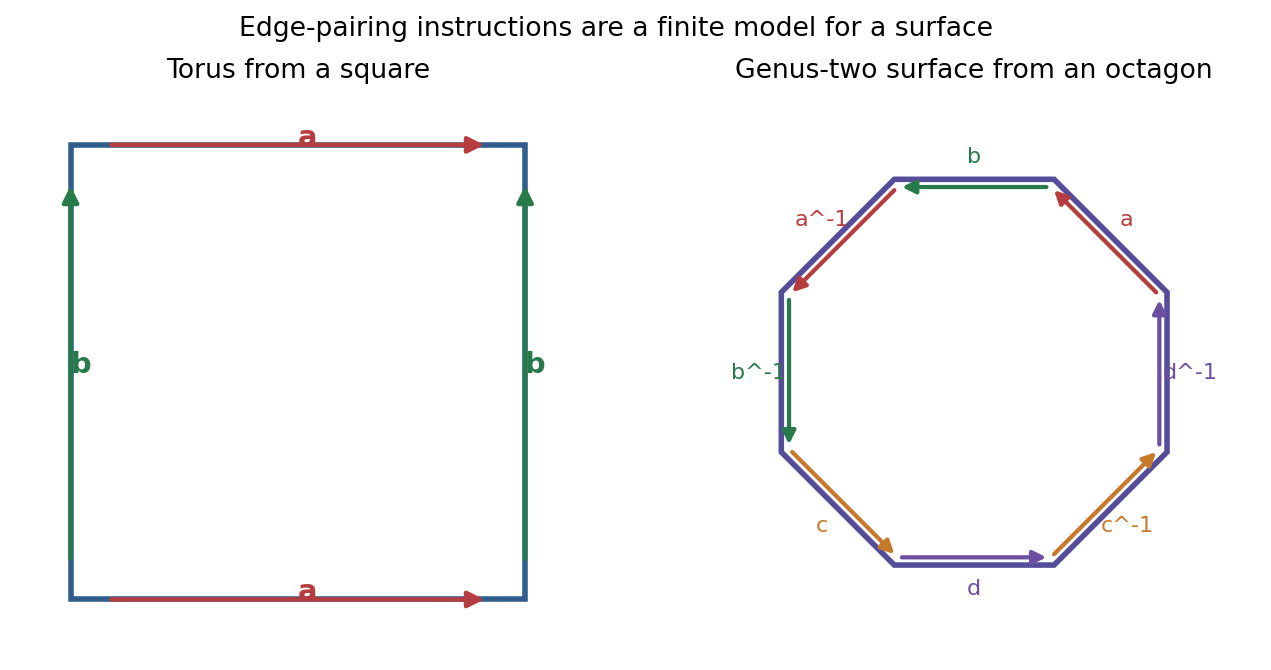

{'torus_square': {'V': 1, 'E': 2, 'F': 1, 'chi': 0, 'genus': 1},
 'genus_two_octagon': {'V': 1, 'E': 4, 'F': 1, 'chi': -2, 'genus': 2},
 'checks': {'torus_chi_zero': True, 'octagon_genus_two': True}}

In [3]:
def polygon_genus(edge_pairs, vertex_classes, faces=1):
    E = len(edge_pairs)
    V = vertex_classes
    chi = V - E + faces
    genus = (2 - chi) // 2
    return {'V': V, 'E': E, 'F': faces, 'chi': chi, 'genus': int(genus)}

torus = polygon_genus(edge_pairs=['a', 'b'], vertex_classes=1)
genus_two = polygon_genus(edge_pairs=['a', 'b', 'c', 'd'], vertex_classes=1)
assert torus['chi'] == 0 and torus['genus'] == 1
assert genus_two['chi'] == -2 and genus_two['genus'] == 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
ax = axes[0]
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, lw=2.5, color='#2f5d8c'))
for start, end, label, color in [((0.08,0),(0.92,0),'a','#b53d3d'), ((0.08,1),(0.92,1),'a','#b53d3d'), ((0,0.08),(0,0.92),'b','#277a4a'), ((1,0.08),(1,0.92),'b','#277a4a')]:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=15, lw=2, color=color))
    ax.text((start[0]+end[0])/2, (start[1]+end[1])/2, label, color=color, fontsize=13, fontweight='bold')
ax.set_title('Torus from a square')
ax.set_aspect('equal'); ax.set_xlim(-.12,1.12); ax.set_ylim(-.12,1.12); ax.axis('off')

ax = axes[1]
angles = np.linspace(0, 2*np.pi, 9)[:-1] + np.pi/8
pts = np.c_[np.cos(angles), np.sin(angles)]
ax.add_patch(Polygon(pts, fill=False, lw=2.5, color='#554c9a'))
labels = ['a','b','a^-1','b^-1','c','d','c^-1','d^-1']
colors = ['#b53d3d','#277a4a','#b53d3d','#277a4a','#c7792b','#6c4ea2','#c7792b','#6c4ea2']
for i, (p, q) in enumerate(zip(pts, np.roll(pts, -1, axis=0))):
    mid = (p + q)/2
    ax.add_patch(FancyArrowPatch(tuple(p*0.96), tuple(q*0.96), arrowstyle='-|>', mutation_scale=12, lw=1.9, color=colors[i]))
    ax.text(mid[0]*1.12, mid[1]*1.12, labels[i], ha='center', va='center', fontsize=10, color=colors[i])
ax.set_title('Genus-two surface from an octagon')
ax.set_aspect('equal'); ax.set_xlim(-1.35,1.35); ax.set_ylim(-1.35,1.35); ax.axis('off')
fig.suptitle('Edge-pairing instructions are a finite model for a surface')
cell_complex_path = remember(save_matplotlib(fig, FIG / 'surface-edge-pairing-board.png'))
plt.close(fig)

ledger = {'torus_square': torus, 'genus_two_octagon': genus_two, 'checks': {'torus_chi_zero': torus['chi'] == 0, 'octagon_genus_two': genus_two['genus'] == 2}}
ledger_path = remember(save_json(ledger, CHECK / 'surface-edge-pairing-board.json'))
display_artifact(cell_complex_path)
ledger


## 2. Hyperbolic Surfaces Through The Disk

The chapter introduces hyperbolic surfaces before the formal machinery arrives. The Poincare disk makes one practical idea testable: hyperbolic lines are Euclidean arcs meeting the boundary circle at right angles. Once that is visible, a quotient by a group of isometries becomes plausible as the curved analogue of the torus quotient by translations.

The next cell draws several geodesics and checks one orthogonality condition numerically. It also records the inversion relation that lets circles and lines swap roles in the inversive model.


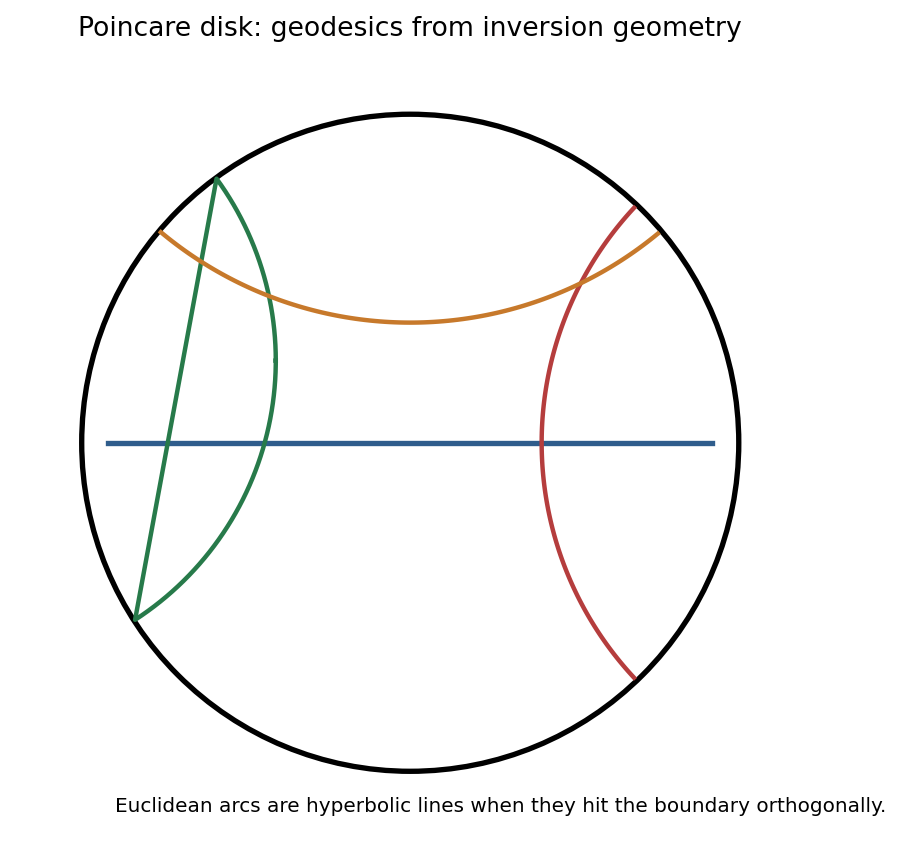

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.add_patch(Circle((0, 0), 1, fill=False, lw=2.4, color='black'))
# Diameter geodesic
ax.plot([-0.92, 0.92], [0.0, 0.0], color='#2f5d8c', lw=2.4, label='diameter geodesic')
# A circle orthogonal to unit circle: center c, radius sqrt(c^2-1)
geodesic_specs = [(1.45, 0.0, '#b53d3d'), (-1.35, 0.25, '#277a4a'), (0.0, 1.55, '#c7792b')]
residuals = []
for cx, cy, color in geodesic_specs:
    c = np.array([cx, cy], float)
    r = math.sqrt(float(c @ c - 1.0))
    theta = np.linspace(0, 2*np.pi, 500)
    xy = c[:, None] + r*np.vstack([np.cos(theta), np.sin(theta)])
    inside = np.sum(xy**2, axis=0) <= 1.0001
    ax.plot(xy[0, inside], xy[1, inside], color=color, lw=2.0)
    # For two orthogonal circles, |c|^2 = r^2 + 1.
    residuals.append(abs(float(c @ c - r*r - 1.0)))
ax.text(-0.9, -1.12, 'Euclidean arcs are hyperbolic lines when they hit the boundary orthogonally.', fontsize=9)
ax.set_title('Poincare disk: geodesics from inversion geometry')
ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.axis('off')
poincare_path = remember(save_matplotlib(fig, FIG / 'poincare-disk-geodesics.png'))
plt.close(fig)
check_path = remember(save_json({'orthogonality_residuals': residuals, 'max_residual': max(residuals), 'check': max(residuals) < 1e-12}, CHECK / 'poincare-disk-geodesics.json'))
assert max(residuals) < 1e-12
display_artifact(poincare_path)


## 3. Totality Of Surfaces: Euler Characteristic And Index

The classification portion of the chapter uses a recurring move: trade a complicated surface for a cell division or a vector field, compute an invariant, and use the invariant to sort possibilities. The diagram below treats the proof as a dependency graph. It also shows why Euler characteristic is not a decorative number: it survives subdivision, connected sum changes it predictably, and it agrees with the sum of vector-field indices.


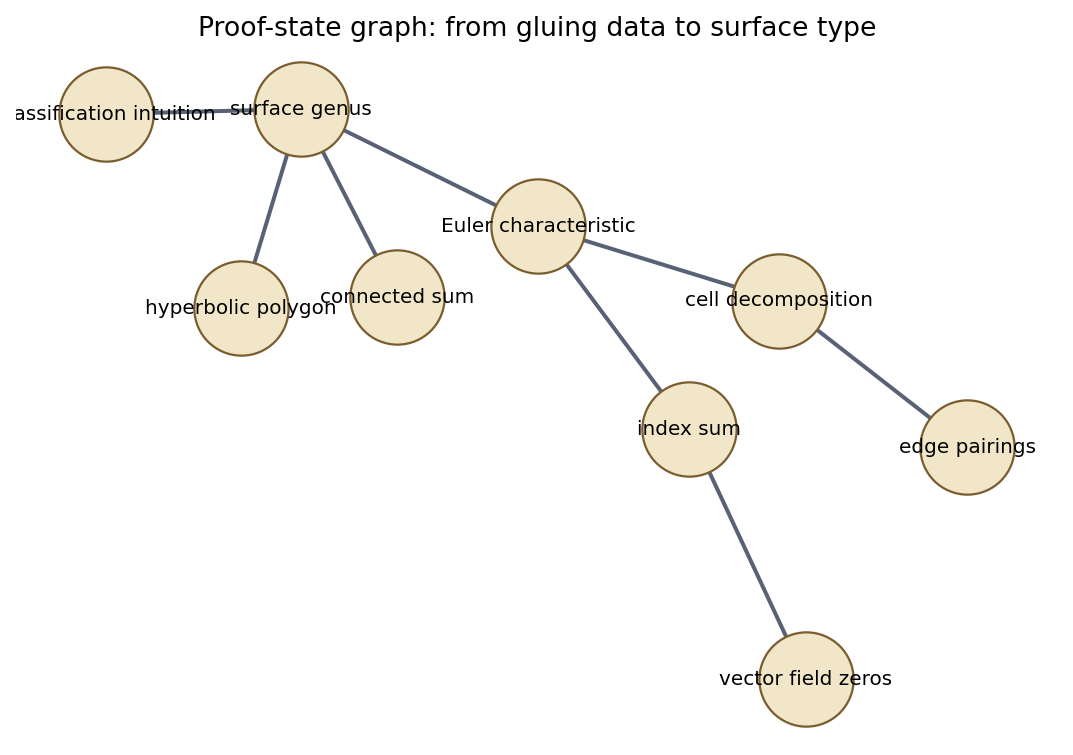

{'sphere': 2, 'torus': 0, 'genus_two': -2, 'torus_sum_genus_two': -4}

In [5]:
G = nx.DiGraph()
edges = [
    ('edge pairings', 'cell decomposition'), ('cell decomposition', 'Euler characteristic'),
    ('vector field zeros', 'index sum'), ('index sum', 'Euler characteristic'),
    ('Euler characteristic', 'surface genus'), ('connected sum', 'surface genus'),
    ('surface genus', 'classification intuition'), ('hyperbolic polygon', 'surface genus'),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=7)
fig, ax = plt.subplots(figsize=(8.4, 5.6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle='-|>', arrowsize=16, width=1.8, edge_color='#596275')
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#f1e7c8', edgecolors='#7a5c2e', node_size=1800)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
ax.set_title('Proof-state graph: from gluing data to surface type')
ax.axis('off')
dep_path = remember(save_matplotlib(fig, FIG / 'surface-classification-proof-graph.png'))
plt.close(fig)
connected = nx.is_weakly_connected(G)

g = sp.symbols('g', integer=True, nonnegative=True)
chi_closed_oriented = sp.simplify(2 - 2*g)
connected_sum_chi = sp.simplify((2 - 2*1) + (2 - 2*2) - 2)  # torus # genus-two
index_ledger = {'sphere': 2, 'torus': 0, 'genus_two': -2, 'torus_sum_genus_two': int(connected_sum_chi)}
assert connected and connected_sum_chi == -4
inv_path = remember(save_json({'graph_weakly_connected': connected, 'chi_formula': str(chi_closed_oriented), 'index_ledger': index_ledger, 'checks': {'torus_sum_genus_two_has_genus_three_chi': connected_sum_chi == -4}}, CHECK / 'what-is-a-manifold-invariants.json'))
display_artifact(dep_path)
index_ledger


## 4. First Three-Manifold Examples

The chapter ends by moving the same gluing imagination up one dimension. A cube with opposite faces identified suggests the three-torus. A ball with antipodal boundary points identified gives projective space. Lens spaces are controlled by a slope on a torus boundary, and the dodecahedral example asks us to believe that a face-pairing can create a closed universe.

The interactive model below is a small inspection board. It does not claim to render the whole quotient space. Instead, it exposes the finite boundary data: three translation directions for the cube and a family of lens-space slopes with a gcd check.


In [6]:
# Plotly boundary-identification board for the 3-torus plus a lens-space slope curve.
cube_edges = []
for x in [0, 1]:
    for y in [0, 1]: cube_edges.append(([x, x], [y, y], [0, 1]))
for x in [0, 1]:
    for z in [0, 1]: cube_edges.append(([x, x], [0, 1], [z, z]))
for y in [0, 1]:
    for z in [0, 1]: cube_edges.append(([0, 1], [y, y], [z, z]))
fig = go.Figure()
for xs, ys, zs in cube_edges:
    fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode='lines', line=dict(color='#2f5d8c', width=5), showlegend=False))
for name, vec, color in [('x face pair', (1.25,0,0), '#b53d3d'), ('y face pair', (0,1.25,0), '#277a4a'), ('z face pair', (0,0,1.25), '#c7792b')]:
    fig.add_trace(go.Cone(x=[0.5], y=[0.5], z=[0.5], u=[vec[0]], v=[vec[1]], w=[vec[2]], sizemode='absolute', sizeref=.35, colorscale=[[0,color],[1,color]], showscale=False, name=name))
# Lens-space slope on a boundary torus.
u = np.linspace(0, 2*np.pi, 260)
p, q = 5, 2
R, r = 2.2, 0.35
x = R + r*np.cos(q*u)
y = r*np.sin(q*u)
z = 0.25*np.sin(p*u)
fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='lines', line=dict(color='#6c4ea2', width=6), name='lens slope (5,2)'))
fig.update_layout(title='Boundary instructions for first three-manifold examples', scene=dict(aspectmode='data'), margin=dict(l=0,r=0,t=40,b=0))
html_path = remember(save_plotly_html(fig, HTML / 'three-manifold-gluing-lab.html'))

slope_rows = []
for p, q in [(1,0), (2,1), (5,2), (7,3), (8,3)]:
    slope_rows.append({'p': p, 'q': q, 'primitive': math.gcd(p, q) == 1, 'lens_label': f'L({p},{q})'})
slope_path = remember(save_csv(slope_rows, TABLE / 'three-manifold-slope-ledger.csv'))
model_path = remember(save_json({'three_torus_generators': ['x', 'y', 'z'], 'lens_slopes': slope_rows, 'checks': {'all_listed_slopes_primitive': all(row['primitive'] for row in slope_rows)}}, CHECK / 'three-manifold-gluing-lab.json'))
assert all(row['primitive'] for row in slope_rows)
display_artifact(html_path, width=820, height=540)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Applied Lab: Predict A Surface From A Pairing Word

The lab distills the first half of the chapter into a reusable computation. For the standard orientable polygon word with `4g` sides, every vertex is identified and the surface has Euler characteristic `2 - 2g`. This cannot replace the classification theorem, but it gives the reader a fast way to test examples before moving to more serious topological arguments.


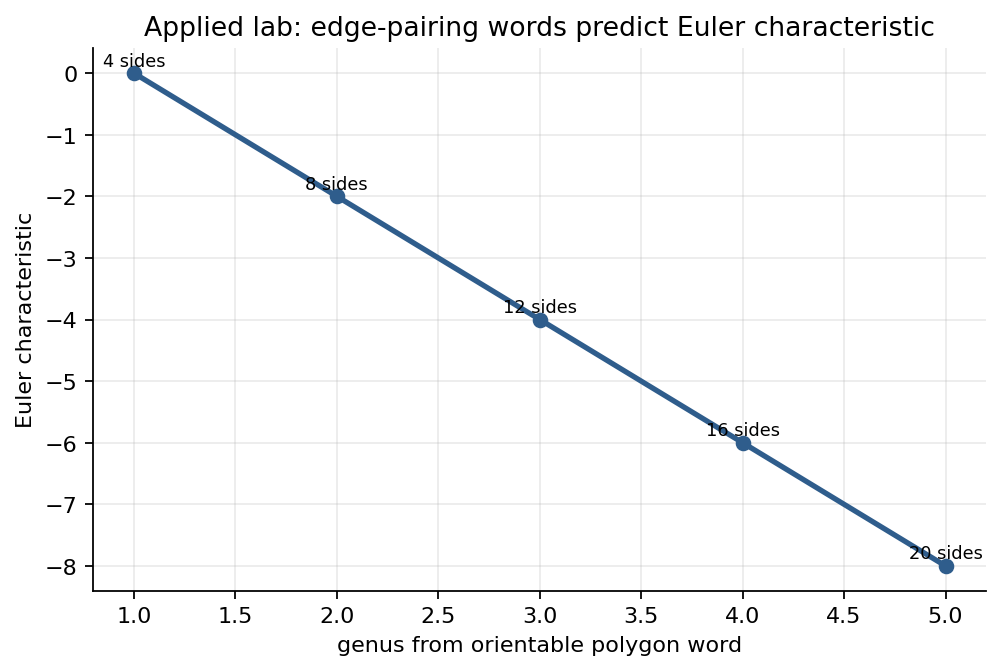

,genus,polygon_sides,V,E,F,chi
0,1,4,1,2,1,0
1,2,8,1,4,1,-2
2,3,12,1,6,1,-4
3,4,16,1,8,1,-6
4,5,20,1,10,1,-8


In [7]:
lab_rows = []
for genus in range(1, 6):
    sides = 4 * genus
    edges_after_pairing = sides // 2
    vertices_after_pairing = 1
    chi = vertices_after_pairing - edges_after_pairing + 1
    lab_rows.append({'genus': genus, 'polygon_sides': sides, 'V': vertices_after_pairing, 'E': edges_after_pairing, 'F': 1, 'chi': chi})
lab_df = pd.DataFrame(lab_rows)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(lab_df['genus'], lab_df['chi'], marker='o', lw=2.4, color='#2f5d8c')
for _, row in lab_df.iterrows():
    ax.text(row['genus'], row['chi'] + 0.12, f"{int(row['polygon_sides'])} sides", ha='center', fontsize=8)
ax.set_xlabel('genus from orientable polygon word')
ax.set_ylabel('Euler characteristic')
ax.set_title('Applied lab: edge-pairing words predict Euler characteristic')
ax.grid(alpha=.25)
lab_fig = remember(save_matplotlib(fig, FIG / 'applied-lab-surface-pairing-ledger.png'))
plt.close(fig)
lab_csv = remember(save_csv(lab_rows, TABLE / 'applied-lab-surface-pairing-ledger.csv'))
lab_json = remember(save_json({'rows': lab_rows, 'checks': {'chi_matches_2_minus_2g': all(row['chi'] == 2 - 2*row['genus'] for row in lab_rows)}}, CHECK / 'surface-pairing-lab.json'))
assert all(row['chi'] == 2 - 2*row['genus'] for row in lab_rows)
display_artifact(lab_fig)
lab_df


## Final Sanity Checks

The final cell treats the chapter as a reproducible visual lesson. It verifies that the generated artifacts exist, that the computed invariants match the claimed surface and gluing facts, and that at least one interactive artifact was produced for the three-dimensional examples.


In [8]:
from PIL import Image, ImageStat
chapter_completion_note = 'TDGT Chapter 1 final_sanity: manifolds from gluing, hyperbolic disk, Euler/index, and first 3-manifold examples.'
assert_artifacts(ARTIFACTS, min_bytes=80)
png_stats = []
for png in sorted(FIG.glob('*.png')):
    with Image.open(png) as img:
        stat = ImageStat.Stat(img.convert('RGB'))
        png_stats.append({'path': png.relative_to(BOOK_ROOT).as_posix(), 'width': img.width, 'height': img.height, 'stddev': max(stat.stddev)})
assert png_stats and all(item['width'] >= 300 and item['height'] >= 250 and item['stddev'] > 1 for item in png_stats)
final_sanity = {
    'unit': UNIT_KEY,
    'source_span': 'printed pages 3-42',
    'artifact_count': len(ARTIFACTS),
    'png_count_in_artifact_tree': len(png_stats),
    'checks': {
        'torus_square_has_genus_one': torus['genus'] == 1,
        'octagon_has_genus_two': genus_two['genus'] == 2,
        'poincare_geodesics_orthogonal': max(residuals) < 1e-12,
        'dependency_graph_connected': connected,
        'surface_pairing_lab_matches_formula': all(row['chi'] == 2 - 2*row['genus'] for row in lab_rows),
    },
    'png_stats': png_stats,
}
final_path = remember(save_json(final_sanity, CHECK / 'final-sanity.json'))
assert_artifacts([final_path], min_bytes=300)
display(Markdown(f"final_sanity passed for **{UNIT_TITLE}** with {len(ARTIFACTS)} tracked artifacts."))
final_sanity


final_sanity passed for **What Is a Manifold?** with 14 tracked artifacts.

{'unit': 'chapter-01-what-is-a-manifold',
 'source_span': 'printed pages 3-42',
 'artifact_count': 13,
 'png_count_in_artifact_tree': 4,
 'checks': {'torus_square_has_genus_one': True,
  'octagon_has_genus_two': True,
  'poincare_geodesics_orthogonal': True,
  'dependency_graph_connected': True,
  'surface_pairing_lab_matches_formula': True},
 'png_stats': [{'path': 'artifacts/chapter-01-what-is-a-manifold/figures/applied-lab-surface-pairing-ledger.png',
   'width': 1002,
   'height': 671,
   'stddev': 37.1554520657303},
  {'path': 'artifacts/chapter-01-what-is-a-manifold/figures/poincare-disk-geodesics.png',
   'width': 901,
   'height': 853,
   'stddev': 41.31768996404362},
  {'path': 'artifacts/chapter-01-what-is-a-manifold/figures/surface-classification-proof-graph.png',
   'width': 1073,
   'height': 755,
   'stddev': 33.9508019119561},
  {'path': 'artifacts/chapter-01-what-is-a-manifold/figures/surface-edge-pairing-board.png',
   'width': 1271,
   'height': 670,
   'stddev': 35.0

## Takeaways

- A manifold can be specified by local models plus gluing instructions; the torus is the first trustworthy laboratory.
- Hyperbolic surface pictures become computable when geodesics are recognized as inversion-compatible arcs in the disk.
- Euler characteristic, connected sum, and vector-field index turn surface classification into a ledger of invariant changes.
- The first three-manifold examples ask for the same skill in one higher dimension: inspect the boundary identifications, then reason about the quotient.
